# 🌿 Plant Disease Image Classification

**Goal:** Classify plant leaf images into one of 38 disease / healthy categories  
**Dataset:** PlantVillage — 54 305 images across 38 classes (multiple plants × multiple diseases)  
**Models:** ResNet-50 and MobileNet-V2 — full network fine-tune (no frozen layers)  
**Training:** Mixed Precision (AMP) + OneCycleLR

---
## Notebook Structure

| Step | Description |
|------|-------------|
| 1 | Dataset overview & class distribution |
| 2 | DataLoader with 70/15/15 stratified split |
| 3 | Load pretrained model weights |
| 4 | Evaluate — accuracy, classification report |
| 5 | Confusion matrix visualisation |
| 6 | Sample predictions gallery |

---
## Step 1 — Dataset Overview

The **PlantVillage** dataset contains images organised in 38 directories.  
Each directory is named `<Plant>___<Disease>` (or `<Plant>___healthy`).

**Why full fine-tuning instead of feature extraction?**  
Full fine-tuning (no frozen layers) lets all convolutional filters adapt to the plant-leaf domain.  
Because PlantVillage images differ substantially from ImageNet (high texture, specific colour palette),  
full fine-tuning consistently outperforms freezing the backbone layers.

**Data augmentation strategy:**  
- Random crop, horizontal/vertical flip, colour jitter on training  
- Deterministic resize + centre on validation / test

In [1]:
import os, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.amp import autocast
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = 'plantvillage dataset'
IMG_SIZE = 224
BATCH_SIZE = 64
print(f'Device: {DEVICE}')

Device: cuda


Total classes : 38
Total images  : 54305
Min / Max per class: 152 / 5507


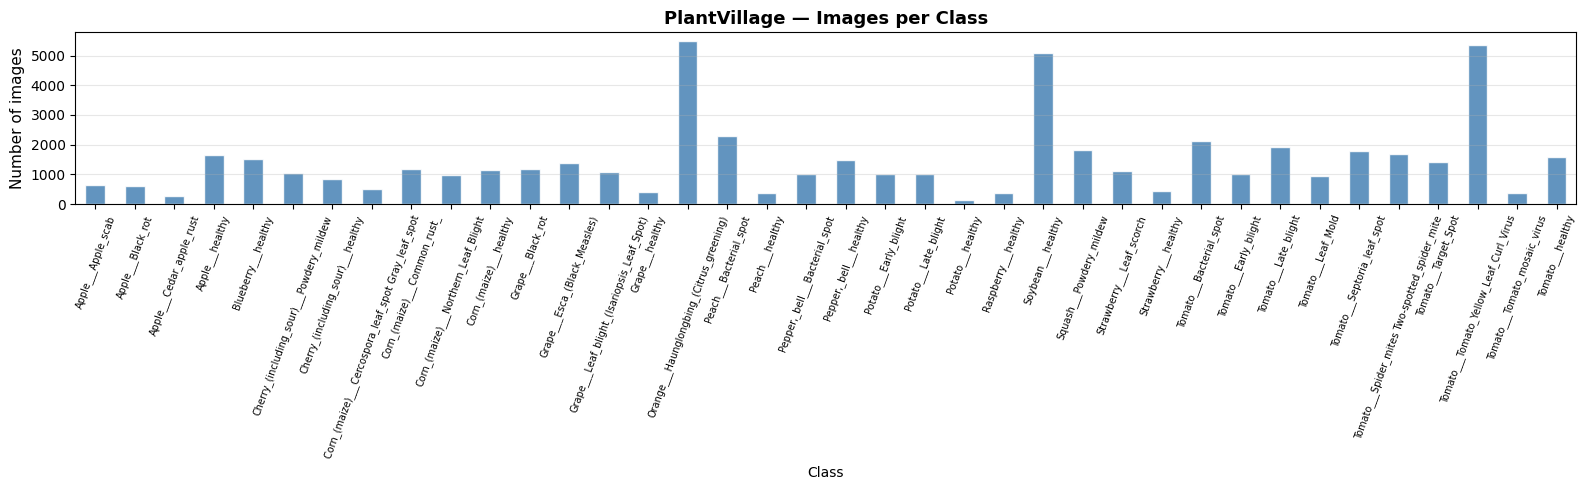

In [2]:
# Load dataset metadata
base_ds = datasets.ImageFolder(DATA_DIR)
class_names = base_ds.classes
NUM_CLASSES = len(class_names)
labels_all  = np.array([s[1] for s in base_ds.samples])

counts = pd.Series(labels_all).value_counts().sort_index()
counts.index = [class_names[i] for i in counts.index]

print(f'Total classes : {NUM_CLASSES}')
print(f'Total images  : {len(base_ds)}')
print(f'Min / Max per class: {counts.min()} / {counts.max()}')

fig, ax = plt.subplots(figsize=(16, 5))
counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xlabel('Class', fontsize=10)
ax.set_ylabel('Number of images', fontsize=11)
ax.set_title('PlantVillage — Images per Class', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=70, labelsize=7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pv_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2 — DataLoader with 70/15/15 Stratified Split

Since the dataset has **no predefined train/val/test split**, we apply `StratifiedShuffleSplit` to ensure each class is proportionally represented in all three splits.  
This prevents imbalanced evaluation when classes differ significantly in size.

In [3]:
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

all_idx = np.arange(len(base_ds))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(all_idx, labels_all))
temp_labels = labels_all[temp_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(temp_idx, temp_labels))
val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

# All use val_tfm for reproducible evaluation
eval_ds  = datasets.ImageFolder(DATA_DIR, transform=val_tfm)
test_ds  = Subset(eval_ds, test_idx)
val_ds   = Subset(eval_ds, val_idx)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f'Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')

Train: 38013  Val: 8146  Test: 8146


---
## Step 3 — Load Pretrained Model Weights

Both models were trained with:
- **Full fine-tuning** — every layer updated from epoch 1  
- **OneCycleLR** — warmup then cosine annealing for stable convergence  
- **Label smoothing (ε = 0.1)** — reduces overconfidence and improves calibration  
- **AMP** — FP16 forward pass for speed

### Why ResNet-50 and MobileNet-V2?

| Model | Params | Key characteristic |
|-------|--------|-----------|
| ResNet-50 | ~25M | Deep residual network, high accuracy |
| MobileNet-V2 | ~3.4M | Inverted residual + depthwise conv — 7× fewer params, fast inference |

In [4]:
def load_model(path: str) -> nn.Module:
    ckpt = torch.load(path, map_location=DEVICE)
    arch = ckpt['arch']
    nc   = ckpt['num_classes']
    if arch == 'resnet50':
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, nc)
    elif arch == 'mobilenet_v2':
        m = models.mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, nc)
    m.load_state_dict(ckpt['state_dict'])
    m = m.to(DEVICE).eval()
    print(f'Loaded {arch}  |  params: {sum(p.numel() for p in m.parameters()):,}')
    print(f'  Best Val Acc: {ckpt["best_val_acc"]:.4f}  |  Test Acc: {ckpt["test_acc"]:.4f}')
    return m

resnet   = load_model('plant_resnet50.pth')
mobilenet = load_model('plant_mobilenet.pth')

Loaded resnet50  |  params: 23,585,894
  Best Val Acc: 0.9977  |  Test Acc: 0.9975
Loaded mobilenet_v2  |  params: 2,272,550
  Best Val Acc: 0.9974  |  Test Acc: 0.9964


---
## Step 4 — Evaluation

In [5]:
def evaluate(model, loader):
    all_preds, all_labels = [], []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for imgs, labs in loader:
            imgs = imgs.to(DEVICE)
            with autocast('cuda' if use_amp else 'cpu'):
                logits = model(imgs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labs.numpy())
    return np.array(all_preds), np.array(all_labels)

print('=== ResNet-50 ===')
res_preds, res_labels = evaluate(resnet, test_loader)
print(f'Test Accuracy: {accuracy_score(res_labels, res_preds):.4f}')

print('\n=== MobileNet-V2 ===')
mob_preds, mob_labels = evaluate(mobilenet, test_loader)
print(f'Test Accuracy: {accuracy_score(mob_labels, mob_preds):.4f}')

=== ResNet-50 ===


Test Accuracy: 0.9975

=== MobileNet-V2 ===


Test Accuracy: 0.9964


In [6]:
# Compact per-class report
res_df = pd.DataFrame(
    classification_report(res_labels, res_preds, target_names=class_names,
                           digits=3, output_dict=True)
).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')

mob_df = pd.DataFrame(
    classification_report(mob_labels, mob_preds, target_names=class_names,
                           digits=3, output_dict=True)
).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')

compare = pd.DataFrame({
    'ResNet-50 F1': res_df['f1-score'],
    'MobileNet-V2 F1': mob_df['f1-score'],
})
print(compare.to_string())

                                                    ResNet-50 F1  MobileNet-V2 F1
Apple___Apple_scab                                      1.000000         0.989247
Apple___Black_rot                                       1.000000         1.000000
Apple___Cedar_apple_rust                                1.000000         1.000000
Apple___healthy                                         1.000000         1.000000
Blueberry___healthy                                     0.997783         0.997783
Cherry_(including_sour)___Powdery_mildew                1.000000         1.000000
Cherry_(including_sour)___healthy                       0.996078         0.996078
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.961538         0.955414
Corn_(maize)___Common_rust_                             1.000000         1.000000
Corn_(maize)___Northern_Leaf_Blight                     0.979452         0.975945
Corn_(maize)___healthy                                  1.000000         1.000000
Grape___Black_ro

---
## Step 5 — Confusion Matrix

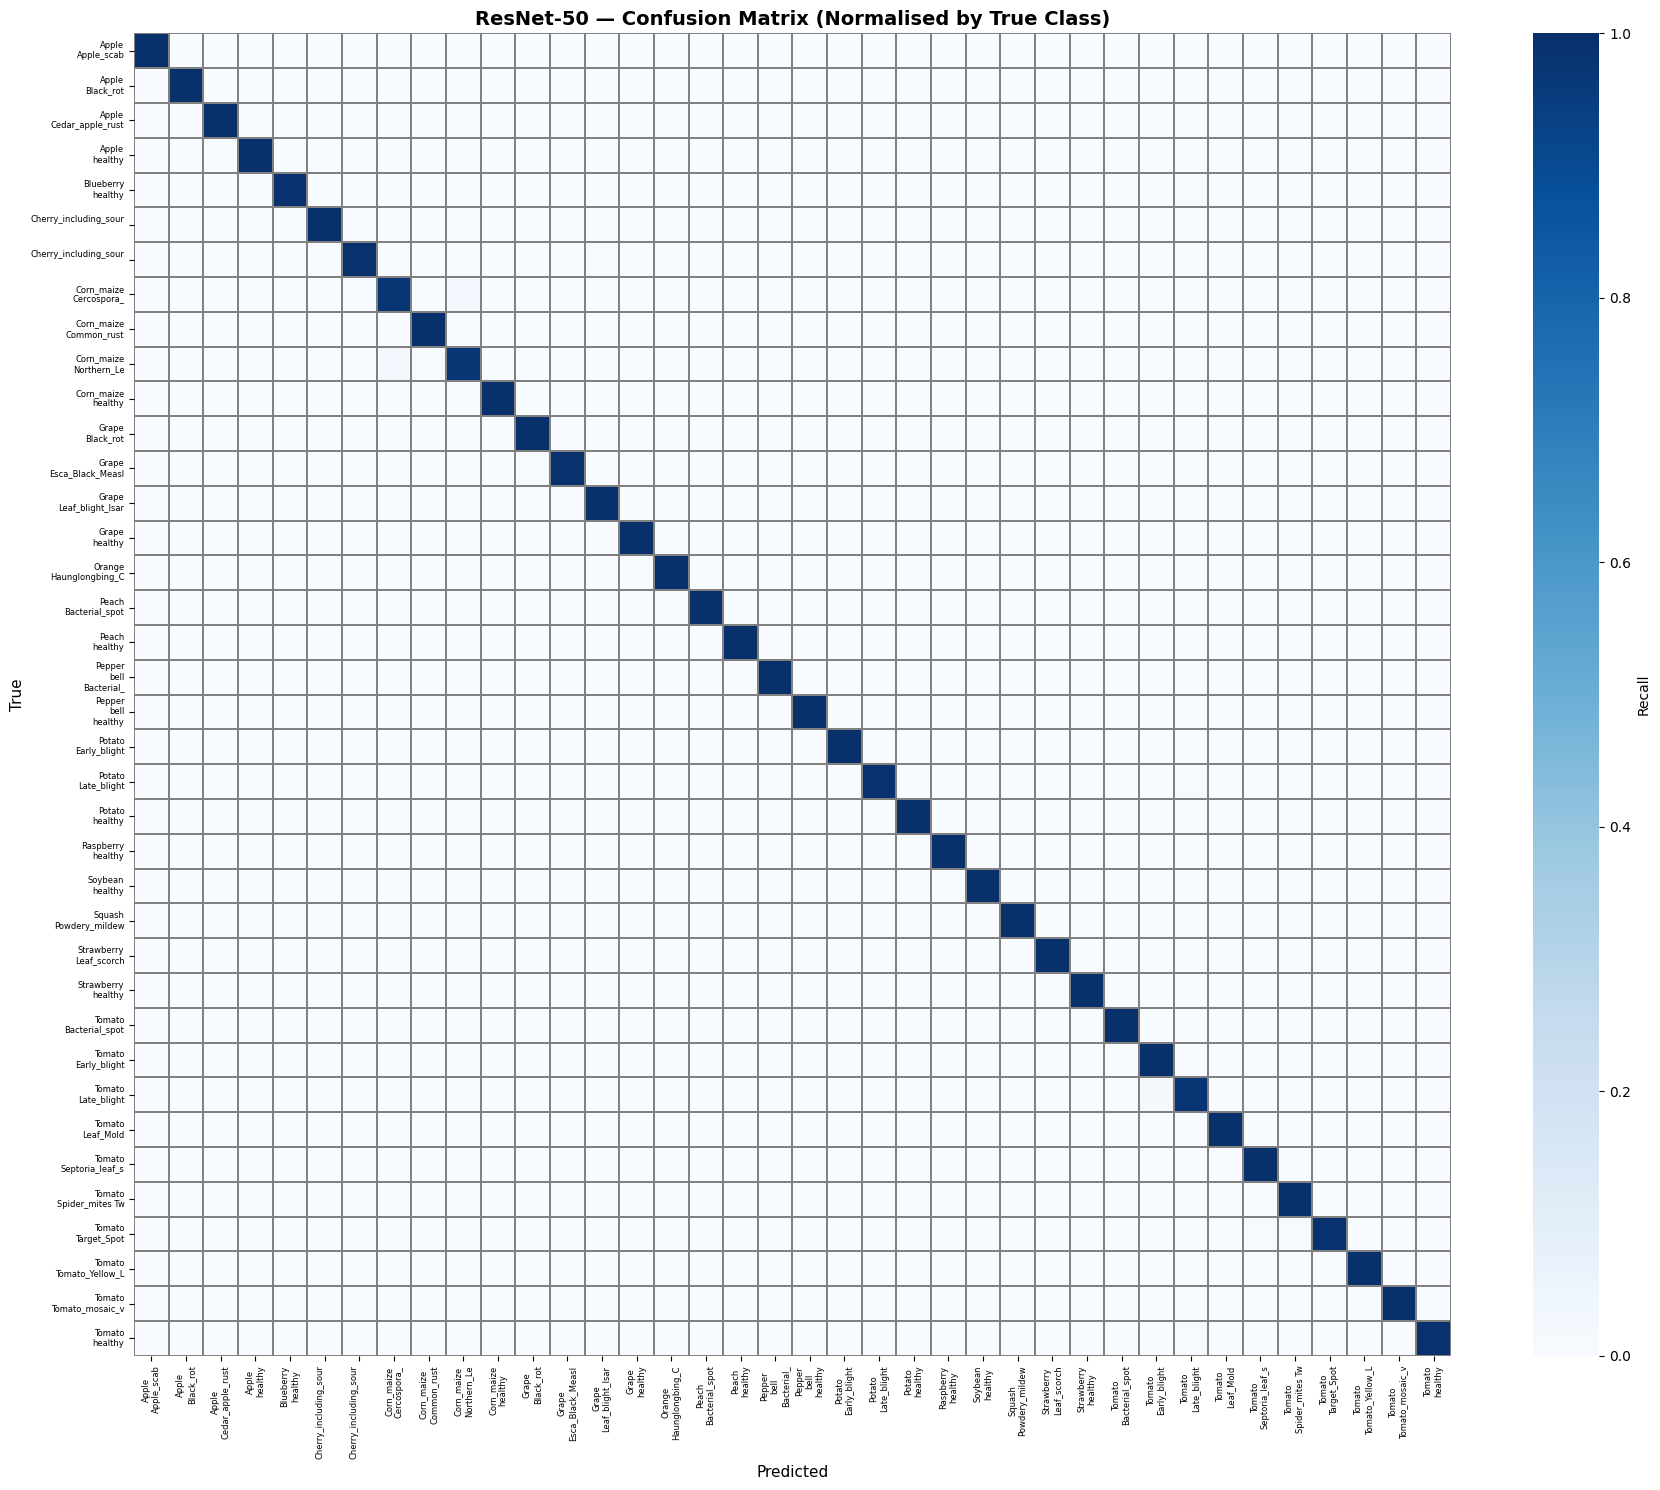

In [7]:
def plot_cm(preds, labels, title, fname, figsize=(18, 15)):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short_names = [c.replace('(', '').replace(')', '').replace(',_', '\n').replace('___', '\n')[:22]
                   for c in class_names]
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm_norm, xticklabels=short_names, yticklabels=short_names,
                cmap='Blues', vmin=0, vmax=1, ax=ax,
                linewidths=0.3, linecolor='grey',
                cbar_kws={'label': 'Recall'})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=6)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_cm(res_preds, res_labels,
        'ResNet-50 — Confusion Matrix (Normalised by True Class)',
        'pv_cm_resnet.png')

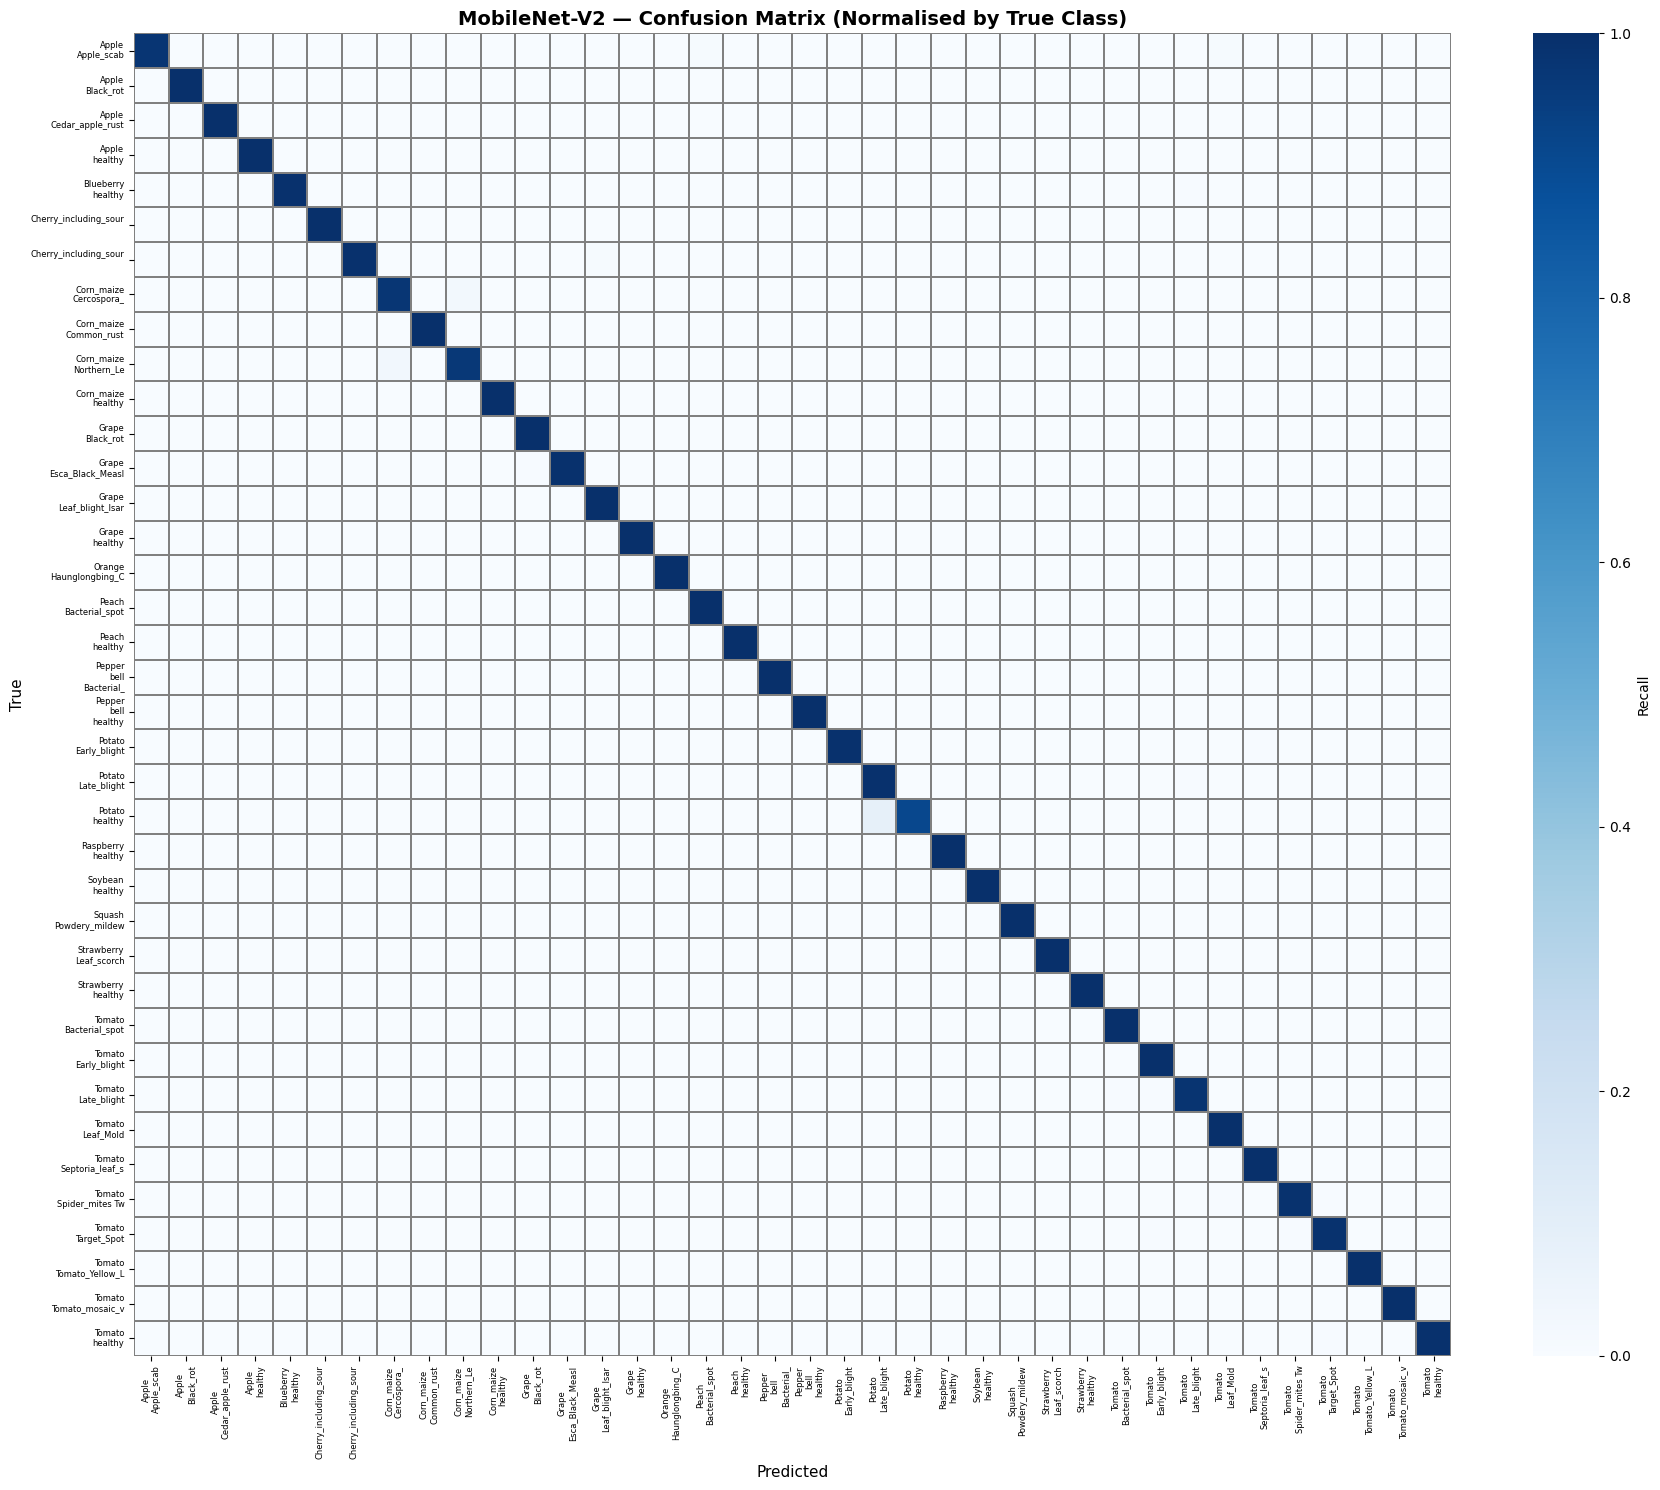

In [8]:
plot_cm(mob_preds, mob_labels,
        'MobileNet-V2 — Confusion Matrix (Normalised by True Class)',
        'pv_cm_mobilenet.png')

---
## Step 6 — Per-Class F1 Comparison

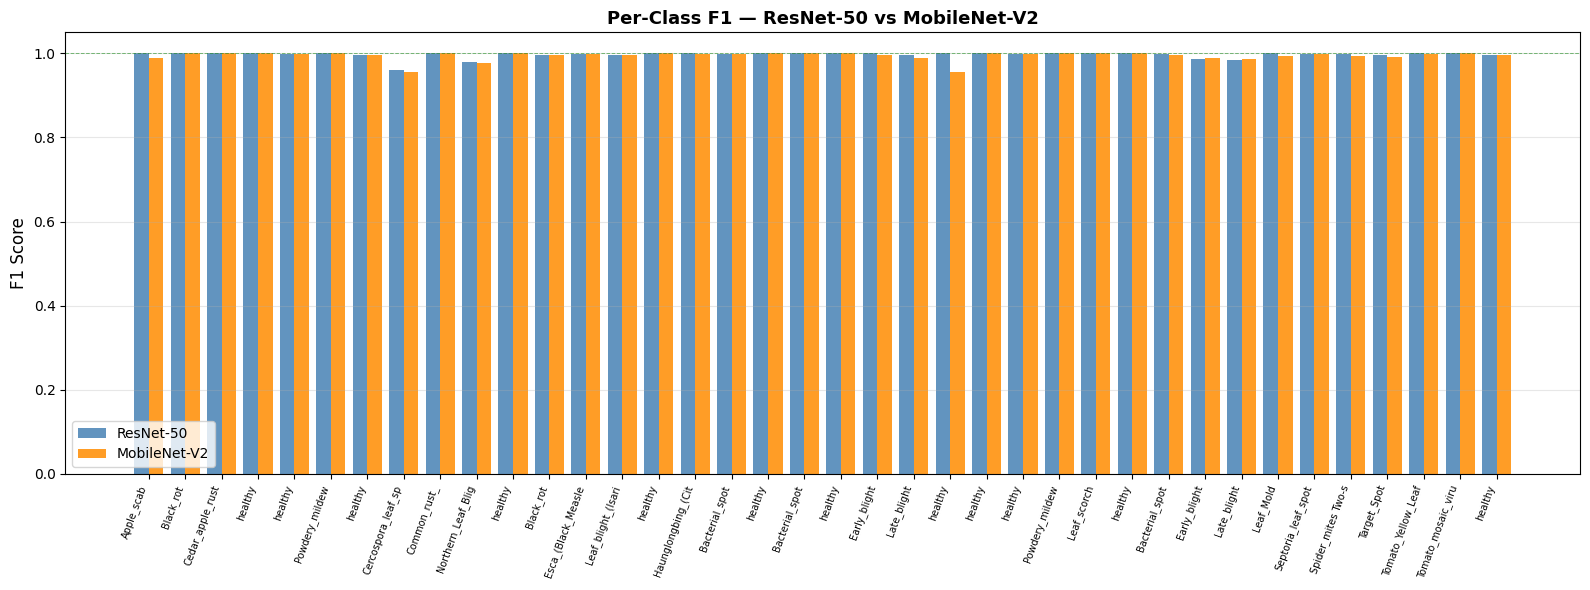

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(NUM_CLASSES)
w = 0.4
ax.bar(x - w/2, compare['ResNet-50 F1'],   w, label='ResNet-50',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, compare['MobileNet-V2 F1'], w, label='MobileNet-V2', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.split('___')[-1][:18] for c in class_names],
                   rotation=70, ha='right', fontsize=7)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 — ResNet-50 vs MobileNet-V2', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='green', lw=0.7, linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pv_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

              Accuracy  Macro F1
ResNet-50     0.997545  0.996784
MobileNet-V2  0.996440  0.994379


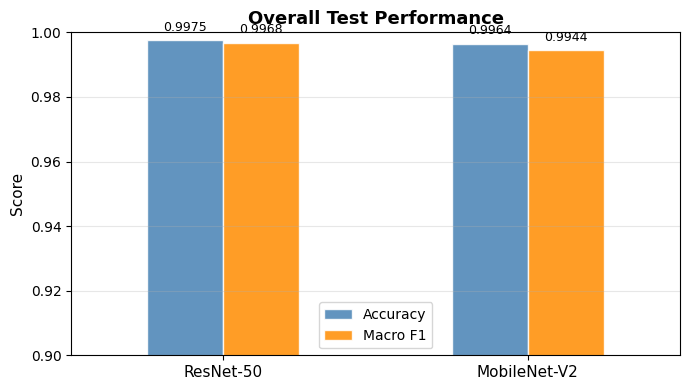

In [10]:
# Overall accuracy + macro-F1 side-by-side bar
from sklearn.metrics import f1_score

metrics = {
    'ResNet-50': {
        'Accuracy': accuracy_score(res_labels, res_preds),
        'Macro F1': f1_score(res_labels, res_preds, average='macro'),
    },
    'MobileNet-V2': {
        'Accuracy': accuracy_score(mob_labels, mob_preds),
        'Macro F1': f1_score(mob_labels, mob_preds, average='macro'),
    },
}
met_df = pd.DataFrame(metrics).T
print(met_df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
met_df.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='white')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.002,
            f'{p.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0.90, 1.0)
ax.set_xticklabels(['ResNet-50', 'MobileNet-V2'], rotation=0, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Overall Test Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pv_overall_perf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Sample Predictions Gallery

A 4×4 grid of test-set images with the true label and the ResNet-50 prediction.  
✅ = correct, ❌ = incorrect.

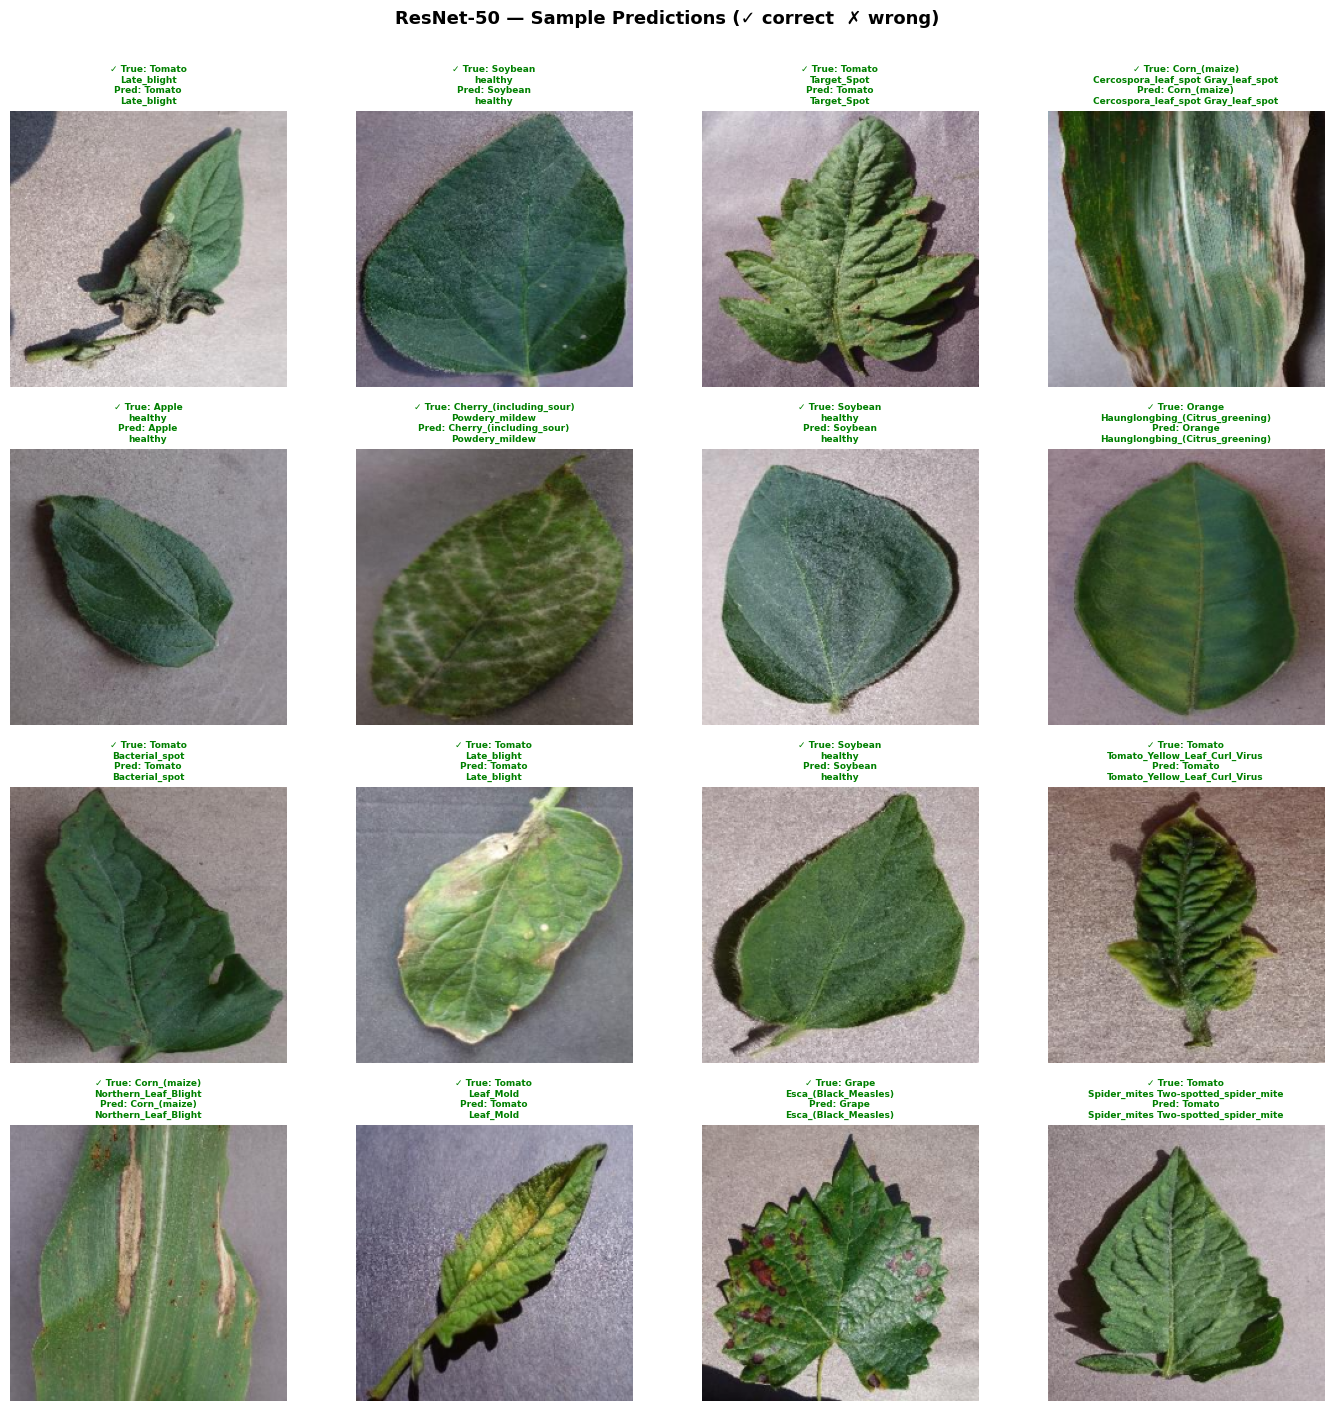

In [11]:
mean_ = np.array([0.485, 0.456, 0.406])
std_  = np.array([0.229, 0.224, 0.225])

def unnorm(t):
    img = t.permute(1,2,0).numpy()
    img = img * std_ + mean_
    return np.clip(img, 0, 1)

# Grab one batch
batch_imgs, batch_labs = next(iter(test_loader))
with torch.no_grad(), autocast('cuda' if DEVICE.type=='cuda' else 'cpu'):
    logits = resnet(batch_imgs.to(DEVICE))
batch_preds = logits.argmax(1).cpu().numpy()

n = 16
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, ax in enumerate(axes.ravel()):
    img = unnorm(batch_imgs[i])
    true_label = class_names[batch_labs[i]].replace('___', '\n')
    pred_label = class_names[batch_preds[i]].replace('___', '\n')
    correct = batch_preds[i] == batch_labs[i].item()
    ax.imshow(img)
    col = 'green' if correct else 'red'
    mark = '✓' if correct else '✗'
    ax.set_title(f'{mark} True: {true_label}\nPred: {pred_label}',
                 fontsize=6.5, color=col, fontweight='bold')
    ax.axis('off')

plt.suptitle('ResNet-50 — Sample Predictions (✓ correct  ✗ wrong)', fontsize=13,
             fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('pv_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()